<a href="https://colab.research.google.com/github/Tak6154/2026_tues_bigdatacomputng_class/blob/main/%EA%B8%B0%EB%A7%90%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok joblib -q  # Streamlit, ngrok, joblib 설치

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 3.9 MB/s eta 0:00:00


In [4]:
import pandas as pd  # 데이터 표 처리
import joblib  # pkl 파일 저장과 불러오기
import matplotlib.pyplot as plt  # 그래프 그리기

from sklearn.model_selection import train_test_split  # 데이터 분할
from sklearn.pipeline import Pipeline  # 파이프라인 생성
from sklearn.preprocessing import PolynomialFeatures  # 다항 특성 생성
from sklearn.preprocessing import StandardScaler  # 표준화 처리
from sklearn.linear_model import LinearRegression  # 선형 회귀 모델
from sklearn.linear_model import Ridge  # Ridge 회귀 모델
from sklearn.metrics import r2_score  # R2 점수 계산
from sklearn.metrics import mean_squared_error  # MSE 계산

In [5]:
url = "https://github.com/dongupak/DataML/raw/main/csv/life_expectancy.csv"  # 데이터 주소

df = pd.read_csv(url)  # CSV 파일 읽기

df.columns = df.columns.str.strip()  # 컬럼명 공백 제거

df = df.dropna()  # 결측치 제거

print("데이터 크기:", df.shape)  # 데이터 크기 출력

display(df.head())  # 데이터 앞부분 확인

데이터 크기: (1649, 22)


,Country,Year,Status,Life expectancy,Adult mortality,Infant deaths,Alcohol,Percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 years,Thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [7]:
target = "Life expectancy"  # 종속변수 설정

features = ["Adult mortality", "BMI", "GDP", "Alcohol", "Polio"]  # 독립변수 설정

X = df[features]  # 독립변수 데이터 생성

y = df[target]  # 종속변수 데이터 생성

print("사용한 독립변수:", features)  # 독립변수 확인

print("사용한 종속변수:", target)  # 종속변수 확인

display(X.head())  # 독립변수 앞부분 확인

display(y.head())  # 종속변수 앞부분 확인

사용한 독립변수: ['Adult mortality', 'BMI', 'GDP', 'Alcohol', 'Polio']
사용한 종속변수: Life expectancy


,Adult mortality,BMI,GDP,Alcohol,Polio
0,263.0,19.1,584.259210,0.01,6.0
1,271.0,18.6,612.696514,0.01,58.0
2,268.0,18.1,631.744976,0.01,62.0
3,272.0,17.6,669.959000,0.01,67.0
4,275.0,17.2,63.537231,0.01,68.0


,Life expectancy
0,65.0
1,59.9
2,59.9
3,59.5
4,59.2


In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(  # train/test 분할
    X,  # 독립변수
    y,  # 종속변수
    test_size=0.2,  # test 20%
    random_state=42  # 결과 고정
)  # 분할 끝

print("전체 train 크기:", X_train_full.shape)  # train 크기 출력

print("test 크기:", X_test.shape)  # test 크기 출력

전체 train 크기: (1319, 5)
test 크기: (330, 5)


In [10]:
X_train = X_train_full.sample(n=50, random_state=42)  # train 중 50개 추출

y_train = y_train_full.loc[X_train.index]  # 같은 인덱스의 y 추출

print("실제 학습 X 크기:", X_train.shape)  # 학습 X 크기 출력

print("실제 학습 y 크기:", y_train.shape)  # 학습 y 크기 출력

실제 학습 X 크기: (50, 5)
실제 학습 y 크기: (50,)


In [11]:
linear_model = Pipeline([  # Linear 파이프라인 생성
    ("poly", PolynomialFeatures(degree=1, include_bias=False)),  # 1차 특성
    ("scaler", StandardScaler()),  # 표준화
    ("model", LinearRegression())  # 선형 회귀
])  # Linear 끝

In [12]:
poly_model = Pipeline([  # Poly 파이프라인 생성
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),  # 3차 특성
    ("scaler", StandardScaler()),  # 표준화
    ("model", LinearRegression())  # 규제 없는 회귀
])  # Poly 끝

In [13]:
ridge_model = Pipeline([  # Ridge 파이프라인 생성
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),  # 3차 특성
    ("scaler", StandardScaler()),  # 표준화
    ("model", Ridge(alpha=1.0))  # Ridge 회귀
])  # Ridge 끝

In [14]:
linear_model.fit(X_train, y_train)  # Linear 학습

poly_model.fit(X_train, y_train)  # Poly 학습

ridge_model.fit(X_train, y_train)  # Ridge 학습

print("Linear 모델 학습 완료")  # Linear 완료

print("Poly 모델 학습 완료")  # Poly 완료

print("Ridge 모델 학습 완료")  # Ridge 완료

Linear 모델 학습 완료
Poly 모델 학습 완료
Ridge 모델 학습 완료


In [15]:
models = {  # 모델 모음
    "Linear": linear_model,  # Linear 저장
    "Poly": poly_model,  # Poly 저장
    "Ridge": ridge_model  # Ridge 저장
}  # 모델 모음 끝

result_list = []  # 결과 리스트

for name in models:  # 모델 이름 반복
    model = models[name]  # 현재 모델 선택

    train_pred = model.predict(X_train)  # train 예측

    test_pred = model.predict(X_test)  # test 예측

    train_r2 = r2_score(y_train, train_pred)  # train R2

    test_r2 = r2_score(y_test, test_pred)  # test R2

    train_mse = mean_squared_error(y_train, train_pred)  # train MSE

    test_mse = mean_squared_error(y_test, test_pred)  # test MSE

    complexity = model.named_steps["poly"].n_output_features_  # 특성 개수

    result = {  # 결과 저장
        "Model": name,  # 모델명
        "Train R2": round(train_r2, 4),  # train R2
        "Test R2": round(test_r2, 4),  # test R2
        "Train MSE": round(train_mse, 4),  # train MSE
        "Test MSE": round(test_mse, 4),  # test MSE
        "Complexity": complexity  # 복잡도
    }  # 결과 끝

    result_list.append(result)  # 리스트에 추가

performance_df = pd.DataFrame(result_list)  # 성능표 생성

display(performance_df)  # 성능표 출력

,Model,Train R2,Test R2,Train MSE,Test MSE,Complexity
0,Linear,0.7337,0.5832,29.1993,29.6014,5
1,Poly,1.0000,-738.7606,0.0000,52539.6345,55
2,Ridge,0.8693,0.5884,14.3303,29.2296,55


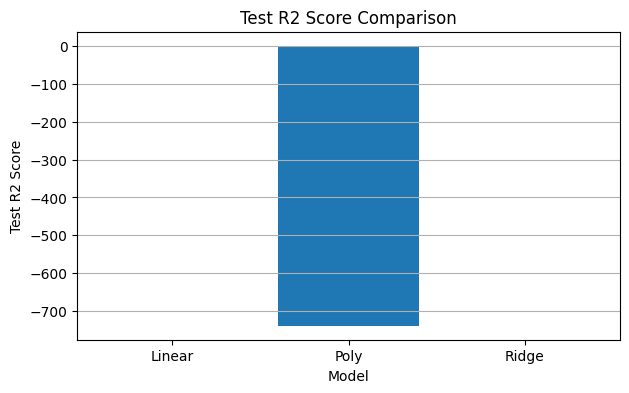

In [16]:
plt.figure(figsize=(7, 4))  # 그래프 크기

plt.bar(performance_df["Model"], performance_df["Test R2"])  # 막대그래프

plt.title("Test R2 Score Comparison")  # 제목

plt.xlabel("Model")  # x축 이름

plt.ylabel("Test R2 Score")  # y축 이름

plt.grid(axis="y")  # y축 격자

plt.show()  # 그래프 출력

In [17]:
joblib.dump(linear_model, "linear_model.pkl")  # Linear 저장

joblib.dump(poly_model, "poly_model.pkl")  # Poly 저장

joblib.dump(ridge_model, "ridge_model.pkl")  # Ridge 저장

print("모델 저장 완료")  # 완료 출력

모델 저장 완료


In [18]:
model_info = {  # 웹앱용 정보
    "features": features,  # 독립변수 목록
    "performance_df": performance_df,  # 성능표
    "feature_min": X.min().to_dict(),  # 최솟값
    "feature_max": X.max().to_dict(),  # 최댓값
    "feature_mean": X.mean().to_dict()  # 평균값
}  # 정보 끝

joblib.dump(model_info, "model_info.pkl")  # 정보 저장

print("model_info.pkl 저장 완료")  # 완료 출력

model_info.pkl 저장 완료


In [29]:
%%writefile app.py
# Streamlit 앱 파일 생성

import streamlit as st  # Streamlit 사용
import pandas as pd  # 데이터프레임 사용
import joblib  # pkl 파일 사용
import matplotlib.pyplot as plt  # 그래프 사용

linear_model = joblib.load("linear_model.pkl")  # Linear 로드

poly_model = joblib.load("poly_model.pkl")  # Poly 로드

ridge_model = joblib.load("ridge_model.pkl")  # Ridge 로드

model_info = joblib.load("model_info.pkl")  # 정보 로드

features = model_info["features"]  # 독립변수 목록

performance_df = model_info["performance_df"]  # 성능표

feature_min = model_info["feature_min"]  # 최솟값

feature_max = model_info["feature_max"]  # 최댓값

feature_mean = model_info["feature_mean"]  # 평균값

models = {  # 모델 모음
    "Linear": linear_model,  # Linear
    "Poly": poly_model,  # Poly
    "Ridge": ridge_model  # Ridge
}  # 모델 모음 끝

st.title("WHO 기대수명 예측 웹 서비스")  # 제목 출력

st.write("다중 특성 회귀 모델로 기대수명을 예측합니다.")  # 설명 출력

st.write("---")  # 구분선

st.header("1. 모델 성능 비교")  # 성능 제목

st.write("Train/Test R2, MSE, Complexity 비교표입니다.")  # 표 설명

st.dataframe(performance_df)  # 성능표 출력

fig, ax = plt.subplots(figsize=(7, 4))  # 그래프 영역

ax.bar(performance_df["Model"], performance_df["Test R2"])  # Test R2 그래프

ax.set_title("Test R2 Score Comparison")  # 제목

ax.set_xlabel("Model")  # x축

ax.set_ylabel("Test R2 Score")  # y축

ax.grid(axis="y")  # 격자

st.pyplot(fig)  # 그래프 출력

st.write("---")  # 구분선

st.header("2. 기대수명 실시간 예측")  # 예측 제목

st.sidebar.header("입력값 조절")  # 사이드바 제목

input_data = {}  # 입력값 저장

for feature in features:  # 특성 반복
    min_value = float(feature_min[feature])  # 최솟값

    max_value = float(feature_max[feature])  # 최댓값

    mean_value = float(feature_mean[feature])  # 기본값

    step_value = float((max_value - min_value) / 100)  # 이동 간격

    input_data[feature] = st.sidebar.slider(  # 슬라이더 생성
        feature,  # 이름
        min_value,  # 최솟값
        max_value,  # 최댓값
        mean_value,  # 기본값
        step_value  # 간격
    )  # 슬라이더 끝

selected_model_name = st.selectbox(  # 모델 선택
    "모델 선택",  # 안내 문구
    ["Linear", "Poly", "Ridge"]  # 선택 목록
)  # 선택 끝

selected_model = models[selected_model_name]  # 선택 모델

input_df = pd.DataFrame([input_data])  # 입력값 표 생성

prediction = selected_model.predict(input_df)[0]  # 기대수명 예측

st.header("예측 결과")  # 결과 제목

st.header(str(round(prediction, 2)) + " 세")  # 큰 글씨 출력

Overwriting app.py


In [25]:
!pip install streamlit pyngrok -q  # Streamlit과 pyngrok 설치

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.9 MB/s eta 0:00:00


In [30]:
import os  # 백그라운드 실행에 사용
import time  # 서버 실행 대기에 사용

os.system("pkill -f streamlit")  # 기존 Streamlit 실행 종료

os.system("nohup streamlit run app.py --server.address 127.0.0.1 --server.port 8501 > /content/logs.txt 2>&1 &")  # Streamlit 실행

time.sleep(3)  # 서버가 켜질 때까지 대기

print("Streamlit 실행 완료")  # 실행 완료 출력

Streamlit 실행 완료


In [31]:
from pyngrok import ngrok  # ngrok 사용

ngrok.kill()  # 기존 ngrok 터널 종료

ngrok.set_auth_token("Here")  # ngrok 토큰 설정

public_url = ngrok.connect(8501, bind_tls=True)  # 8501 포트를 public URL로 연결

print("Streamlit Public URL:")  # 안내 출력

print(public_url)  # 접속 URL 출력

Streamlit Public URL:
NgrokTunnel: "https://oyster-manhole-humid.ngrok-free.dev" -> "http://localhost:8501"


## 웹 서비스 실행 화면 캡처본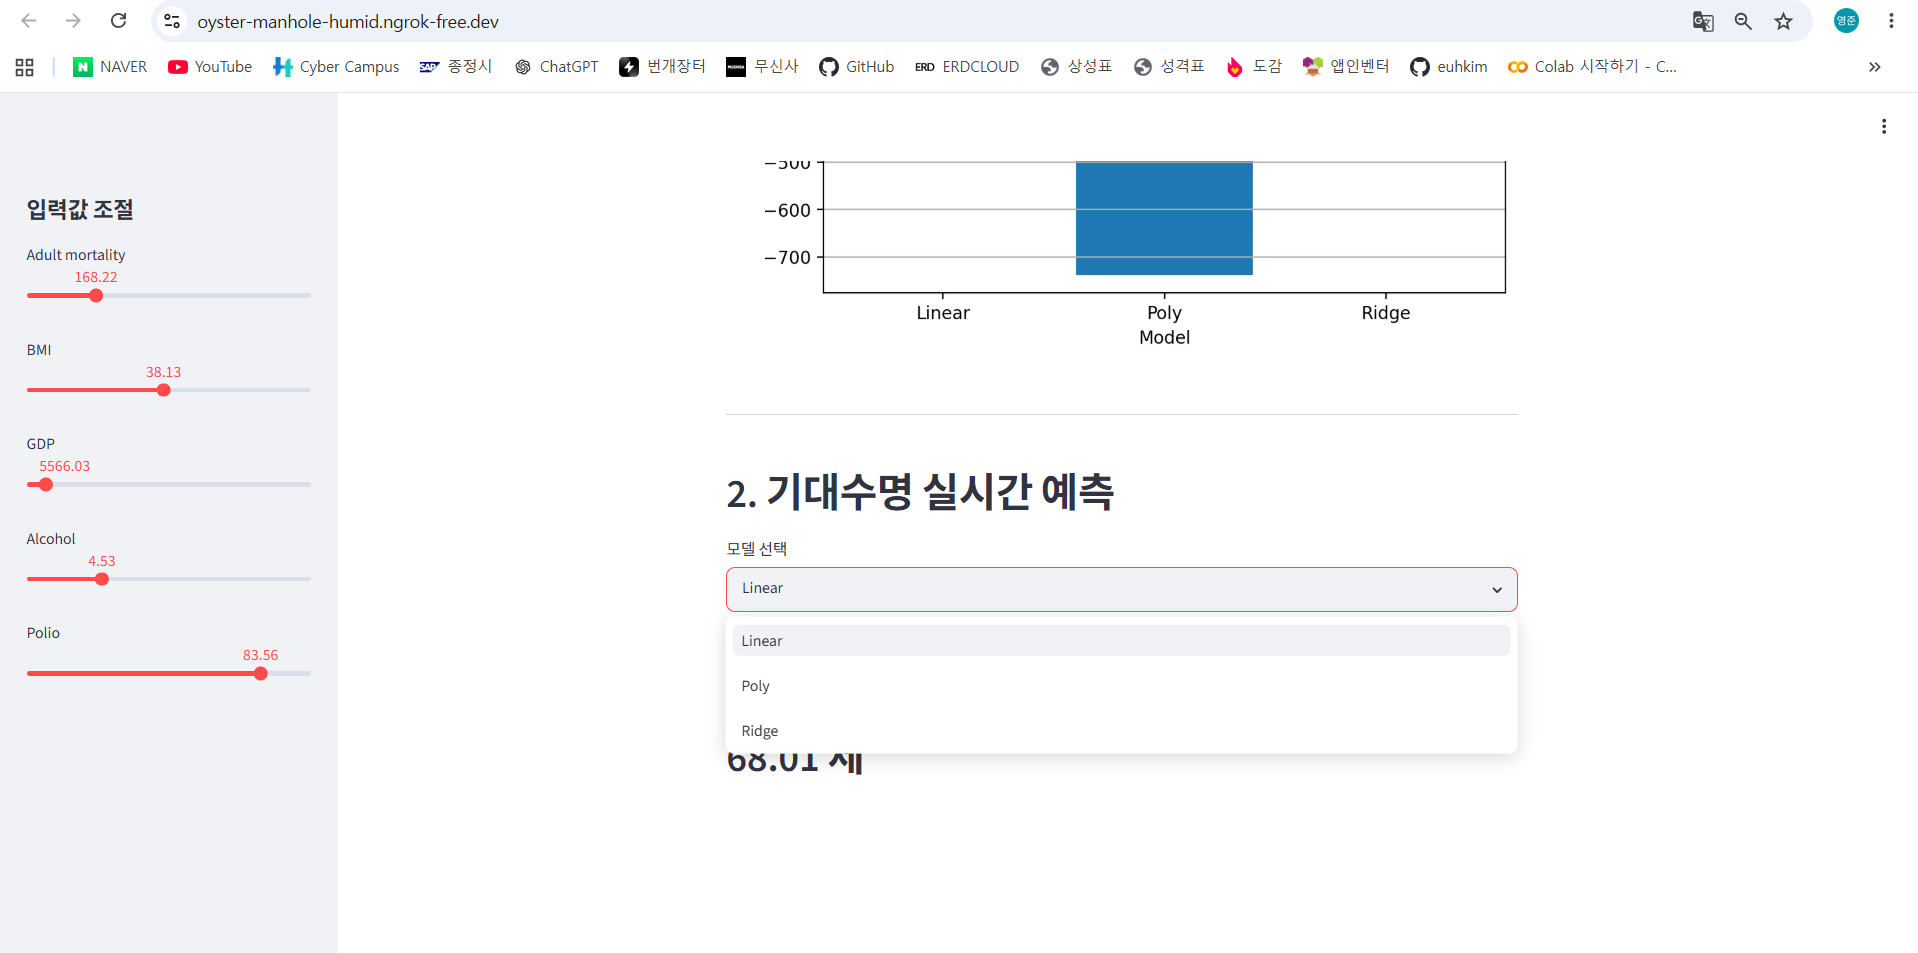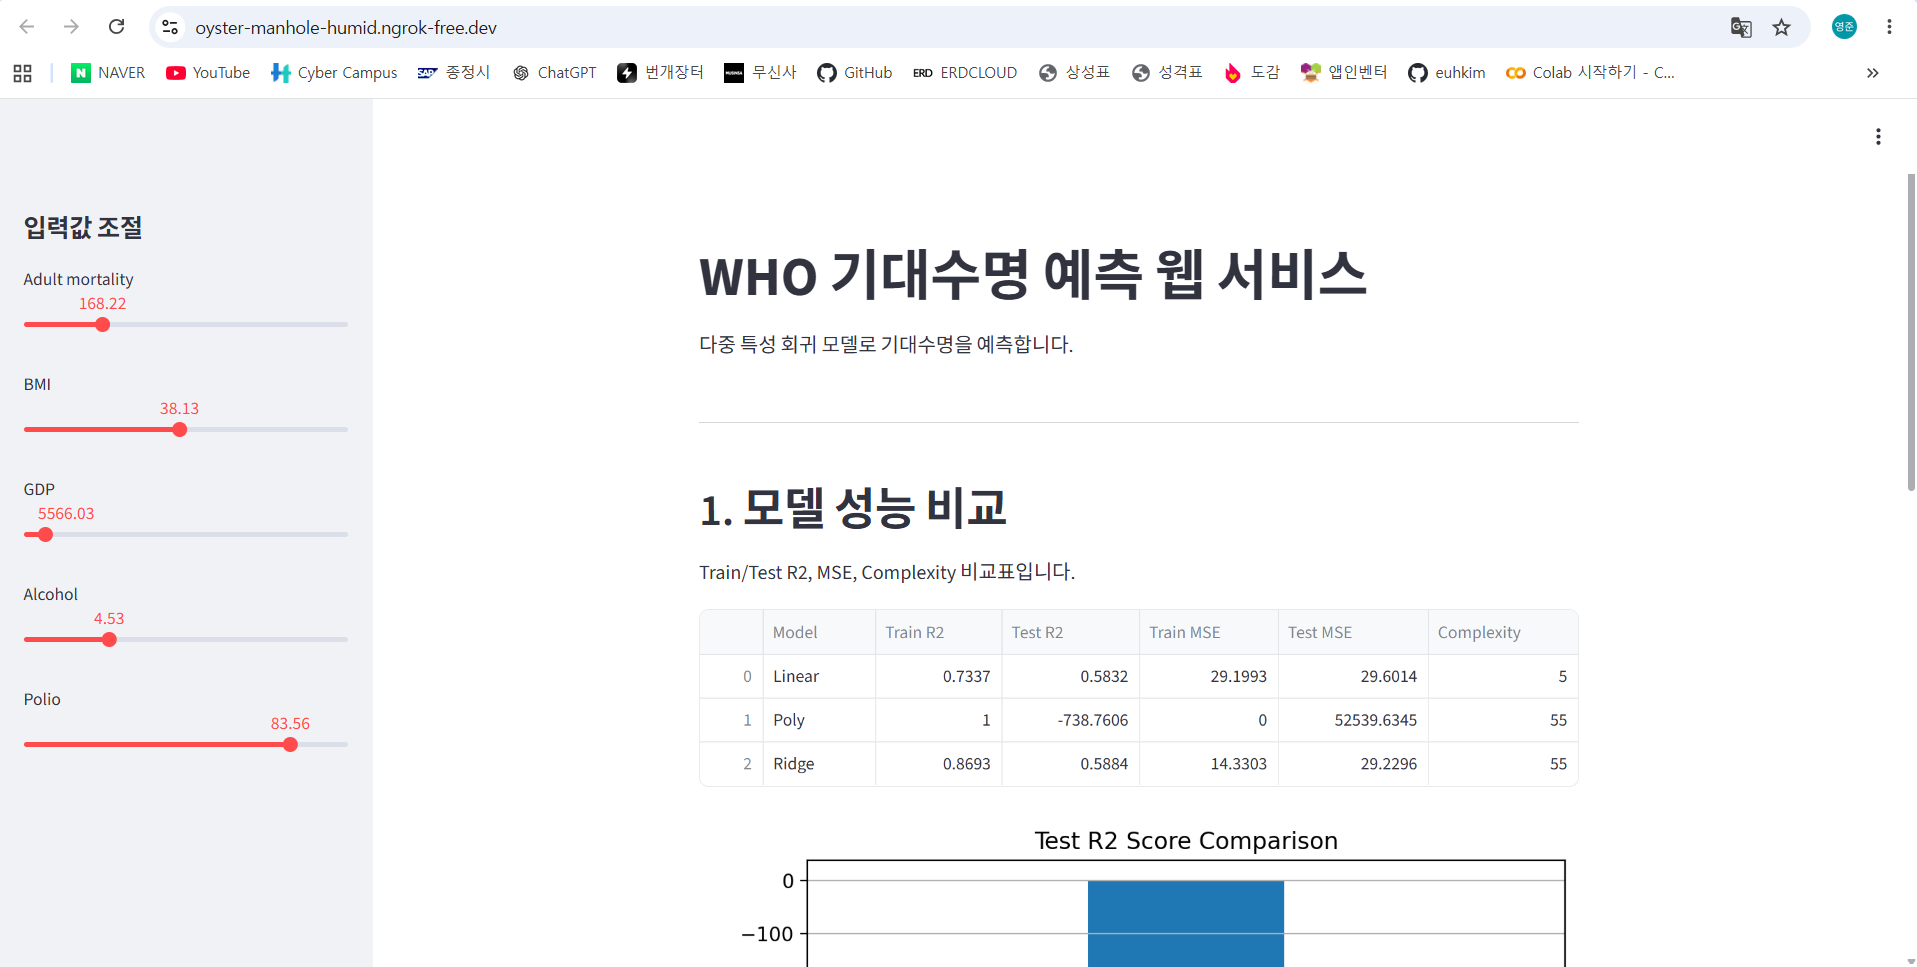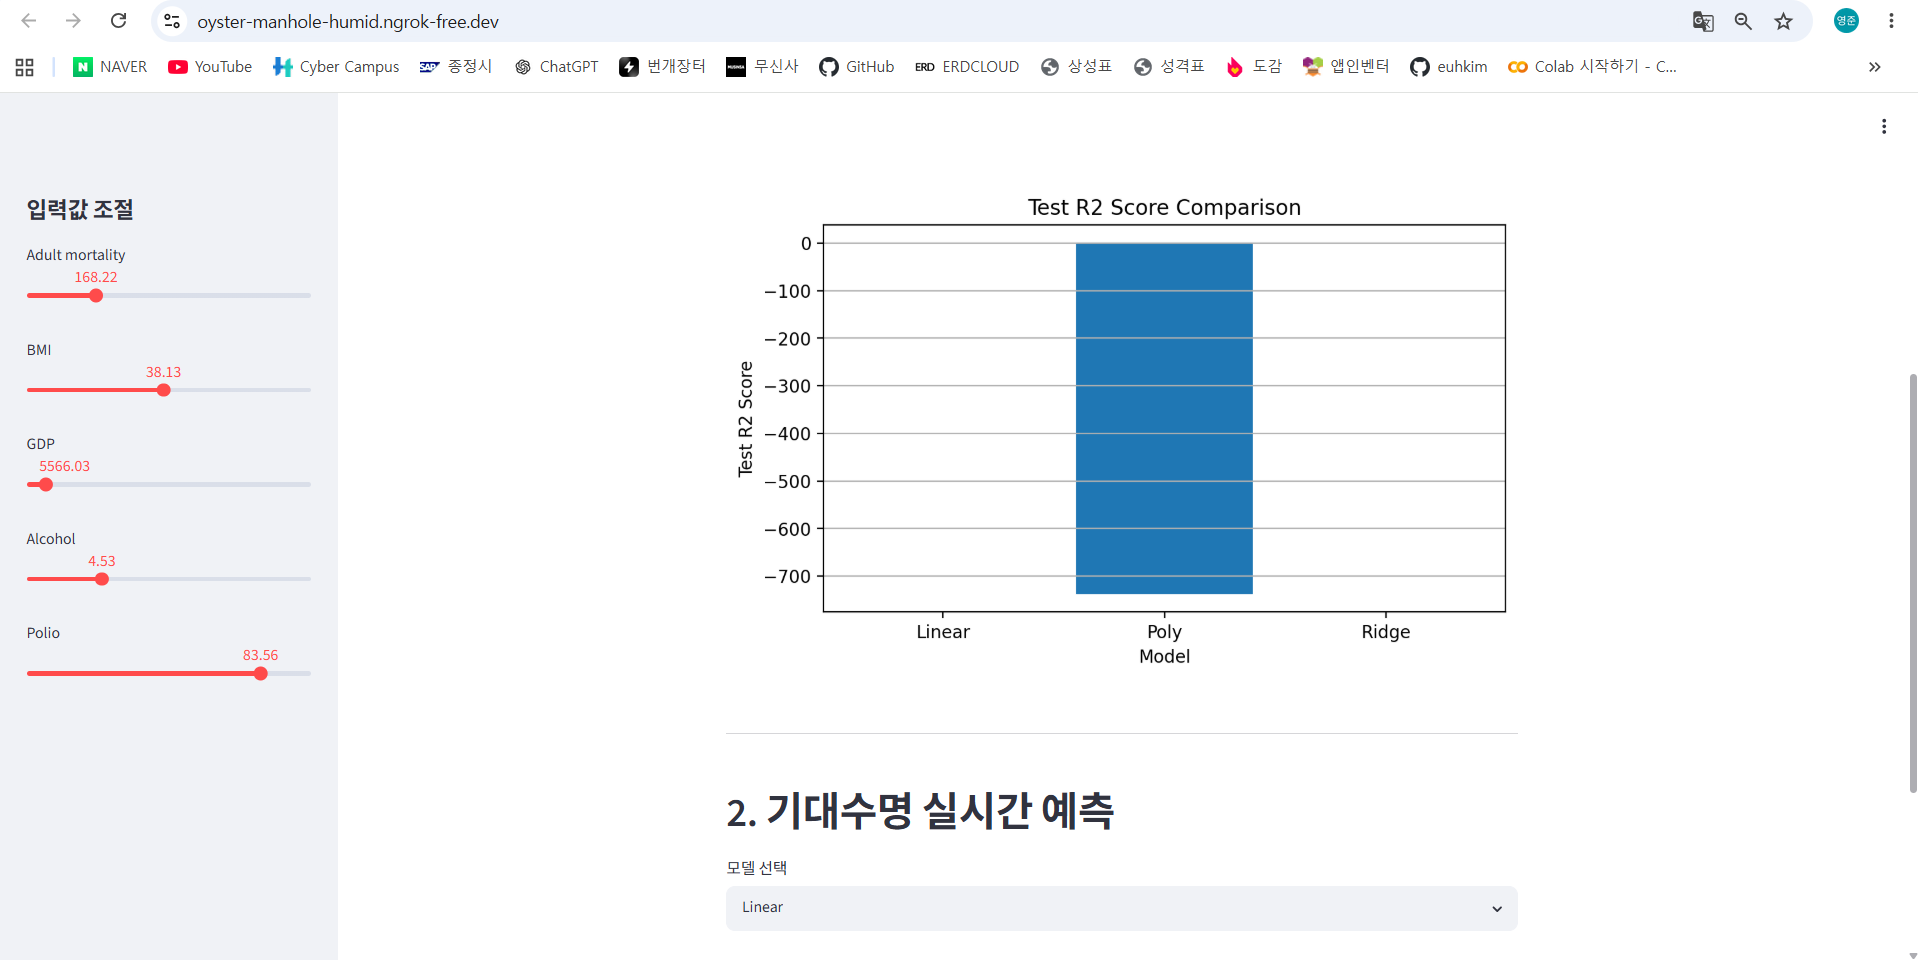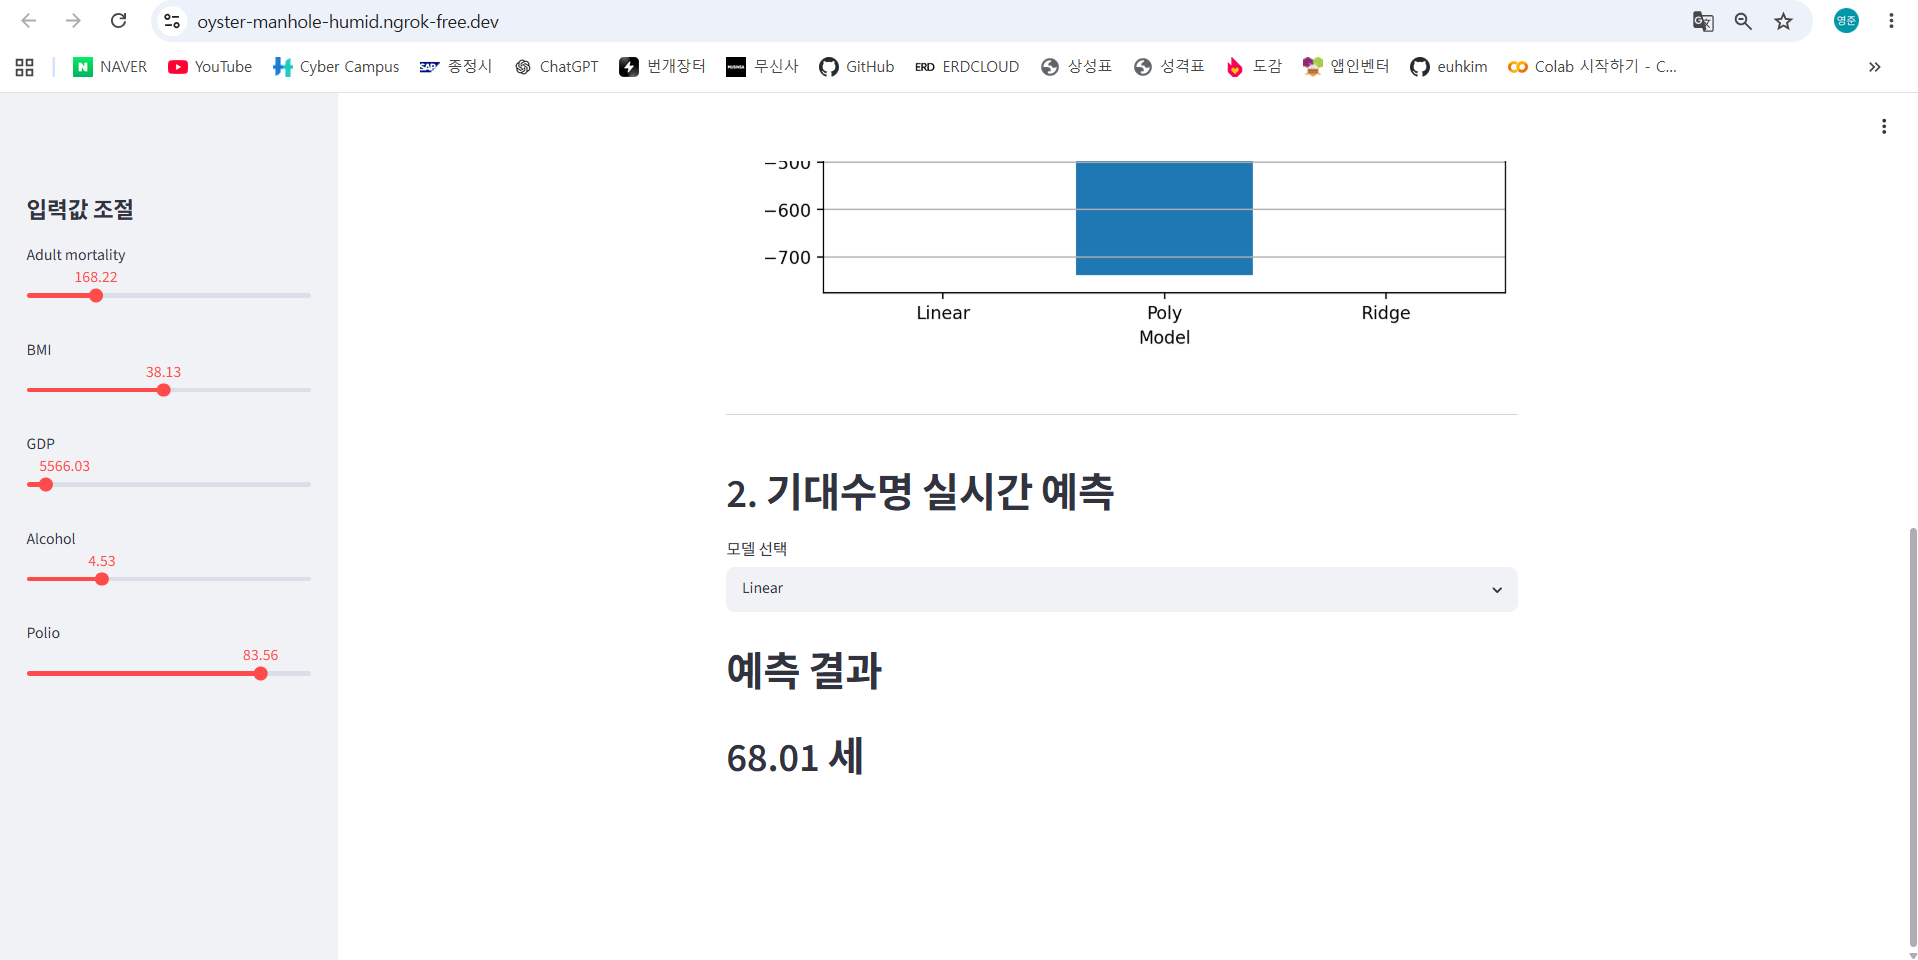